# Tuning hyperparameters

Set directory

In [ ]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [ ]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

## Import model and choose parameter search grid

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from Modules.Load_RF_forecast_models import load_rf_models

# load_rf_models currently supports only the optional timeout argument.
rf_models = load_rf_models(user="Christine - desktop")      # set user to "Nikolaj" or "Christine"
# wandb api: wandb_v1_Q06Vm5akOKLtJXwpM9PMWBzX9UO

# Initialize model:
model = LinearRegression()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    'fit_intercept': [True, False],
}

num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


## Choose validation setup


**Setup 1**

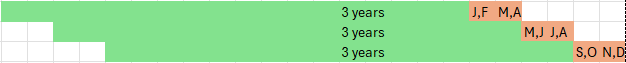

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [ ]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Test train / val split function:

In [ ]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

folds = _build_validation_folds(
    data=DK1_train,
    train_window=3 * 8760,        # 8760 hours = 1 year
    val_window=8784,
    val_start="2024-01-01 00:00:00",
    predict_period=4 * 168,         # 168 hours = 1 week
    stride=13 * 168,               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=8760 - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Fold {folds[1]['fold']} train start: {folds[1]['train_start']} - train end: {folds[1]['train_end']}")
print(f"Number of folds: {num_folds}")
print(f"Validation window start: {val_start} - validation window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} val start: {folds[fold]['val_start']} - val end: {folds[fold]['val_end']}")

In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

param_grid = {
    'fit_intercept': [True, False],
}

num_combinations = np.prod([len(v) for v in param_grid.values()])

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        val_window = 1 * 8784,
        val_start = "2024-01-01 00:00:00",
        predict_period = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,               # stride between predict_periods              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "LinReg")
base_filename = "DK1_hyperparameter_results_linreg_LR.csv"          # Name the results file
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        val_window = 1 * 8784,
        val_start = "2024-01-01 00:00:00",
        predict_period = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,               # stride between predict_periods              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "LinReg")
base_filename = "DK2_hyperparameter_results_linreg_LR.csv"          # Name the results file
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


## Train and test final model

Make train and test periods

In [ ]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=len(train_data),        # 8760 hours = 1 year
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Train and test the final model

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from Modules.Validation2 import run_cross_validation
import os

# Set price zone and parameters
# ========================
price_zone = "DK1"

params = {
    'fit_intercept': True,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

model = LinearRegression(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,  # ignored in Validation2 but safe to keep
    train_window=len(train_data),  # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
)

row = {
    **params,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "LinReg")
base_filename = f"{price_zone}_final_LR_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from Modules.Validation2 import run_cross_validation
import os

# Set price zone and parameters
# ========================
price_zone = "DK2"

params = {
    'fit_intercept': False,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

model = LinearRegression(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,  # ignored in Validation2 but safe to keep
    train_window=len(train_data),  # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
)

row = {
    **params,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "LinReg")
base_filename = f"{price_zone}_final_LR_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")